In [6]:
# Main Title (Heading 1)
## Major Section (Heading 2)
### Subsection (Heading 3)
#### Sub-subsection (Heading 4)
##### Small Heading (Heading 5)
###### Smallest Heading (Heading 6)
print ('Hi Anaconda py 3.13')

Hi Anaconda py 3.13


<h1 style="color:blue; font-size:35px; font-weight:bold;">Insert Data</h1>

In [ ]:
import pandas as pd

file_path = r".....\Data\All_Processed_Survey_Data_Conda.csv"

df = pd.read_csv(file_path, encoding="latin1")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (20496, 13)


,Sequence,Name,Latitude,Longitude,Distance,Travel Time (s),Dwell Time (s),Boarding,Alighting,Occupancy,Trip_ID,Route_ID,Time
0,3,Abdullahpur,23.877466,90.401161,NaN,1027.000000,230.000000,10.0,23.0,39.0,1 MP_F,A-132,9:37:51 AM
1,3,Abdullahpur,23.877466,90.401161,NaN,262.000000,552.000000,16.0,16.0,29.0,2 MP_B,A-132,10:35:22 AM
2,3,Abdullahpur,23.877466,90.401161,NaN,358.999999,610.000001,11.0,30.0,34.0,3 NOP_F,A-132,1:12:26 PM
3,3,Abdullahpur,23.877466,90.401161,NaN,668.000000,223.000000,21.0,7.0,36.0,4 NOP_B,A-132,2:35:33 PM
4,3,Abdullahpur,23.877466,90.401161,NaN,957.000000,210.000000,16.0,22.0,23.0,5 AP_F,A-132,4:34:29 PM


In [16]:
# ============================================================
# DTCA / BRR BUS SURVEY DATA
# LOAD + INITIALIZE ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.2f}"
)

# ============================================================
# 1. FILE PATH
# ============================================================

file_path = (
    r"E:\DTCA Project\BRR Project\Survey Data"
    r"\Data Processing\Data Visualization Code"
    r"\Python Anaconda\Data"
    r"\All_Processed_Survey_Data_Conda.csv"
)

# ============================================================
# 2. LOAD ORIGINAL DATA
# ============================================================

try:

    df = pd.read_csv(
        file_path,
        encoding="latin1"
    )

    print("=" * 80)
    print("DATASET SUCCESSFULLY LOADED")
    print("=" * 80)

except FileNotFoundError:

    print("ERROR: File not found.")
    print("\nPython searched for:")
    print(file_path)

    raise

except UnicodeDecodeError:

    print("ERROR: Encoding problem.")
    print("The file could not be read using latin1 encoding.")

    raise

# ============================================================
# 3. PRESERVE ORIGINAL DATA
# ============================================================

df_raw = df.copy()

# ============================================================
# 4. CREATE WORKING ANALYSIS DATASET
# ============================================================

df_analysis = df.copy()

# ============================================================
# 5. BASIC VALIDATION
# ============================================================

print("\n" + "=" * 80)
print("DATASET INFORMATION")
print("=" * 80)

print(f"Rows:    {len(df_analysis):,}")
print(f"Columns: {len(df_analysis.columns):,}")

print("\nColumn names:")
for i, column in enumerate(df_analysis.columns, start=1):
    print(f"{i:2}. {column}")

print("\nData types:")
display(df_analysis.dtypes.to_frame("Data Type"))

print("\nFirst 5 records:")
display(df_analysis.head())

print("\nMissing values:")
missing = (
    df_analysis.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_table = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percent": (
        missing / len(df_analysis) * 100
    )
})

display(missing_table)

DATASET SUCCESSFULLY LOADED

DATASET INFORMATION
Rows:    20,496
Columns: 13

Column names:
 1. Sequence 
 2. Name
 3. Latitude
 4. Longitude
 5. Distance
 6. Travel Time (s)
 7. Dwell Time (s)
 8. Boarding
 9. Alighting
10. Occupancy
11. Trip_ID
12. Route_ID
13. Time

Data types:


,Data Type
Sequence,int64
Name,str
Latitude,float64
Longitude,float64
Distance,float64
Travel Time (s),float64
Dwell Time (s),float64
Boarding,float64
Alighting,float64
Occupancy,float64



First 5 records:


,Sequence,Name,Latitude,Longitude,Distance,Travel Time (s),Dwell Time (s),Boarding,Alighting,Occupancy,Trip_ID,Route_ID,Time
0,3,Abdullahpur,23.88,90.40,NaN,"1,027.00",230.00,10.00,23.00,39.00,1 MP_F,A-132,9:37:51 AM
1,3,Abdullahpur,23.88,90.40,NaN,262.00,552.00,16.00,16.00,29.00,2 MP_B,A-132,10:35:22 AM
2,3,Abdullahpur,23.88,90.40,NaN,359.00,610.00,11.00,30.00,34.00,3 NOP_F,A-132,1:12:26 PM
3,3,Abdullahpur,23.88,90.40,NaN,668.00,223.00,21.00,7.00,36.00,4 NOP_B,A-132,2:35:33 PM
4,3,Abdullahpur,23.88,90.40,NaN,957.00,210.00,16.00,22.00,23.00,5 AP_F,A-132,4:34:29 PM



Missing values:


,Missing_Count,Missing_Percent
Distance,20496,100.00
Time,5353,26.12
Trip_ID,45,0.22
Dwell Time (s),1,0.00
Travel Time (s),1,0.00
Alighting,1,0.00
Boarding,1,0.00
Occupancy,1,0.00
Sequence,0,0.00
Longitude,0,0.00


In [17]:
# ============================================================
# DTCA / BRR BUS SURVEY DATA
# FIVE-AREA ANALYSIS PIPELINE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# ------------------------------------------------------------
# 0. PRESERVE ORIGINAL DATA
# ------------------------------------------------------------

df_raw = df.copy()

# Working copy
df_analysis = df.copy()

print("=" * 80)
print("DATASET LOADED")
print("=" * 80)
print(f"Rows:    {len(df_analysis):,}")
print(f"Columns: {len(df_analysis.columns):,}")

DATASET LOADED
Rows:    20,496
Columns: 13


<h1 style="color:purple; font-size:30px; font-weight:bold;">1. DATA PREPARATION</h1>

In [51]:
# ============================================================
# 1. DATA PREPARATION
# ============================================================

# ------------------------------------------------------------
# 1.1 Convert time to datetime/time
# ------------------------------------------------------------

df_analysis["Time_Parsed"] = pd.to_datetime(
    df_analysis["Time"],
    format="%I:%M:%S %p",
    errors="coerce"
)

# Extract hour
df_analysis["Hour"] = df_analysis["Time_Parsed"].dt.hour

# Extract minute
df_analysis["Minute"] = df_analysis["Time_Parsed"].dt.minute

# Decimal hour
df_analysis["Decimal_Hour"] = (
    df_analysis["Hour"] +
    df_analysis["Minute"] / 60
)

# ------------------------------------------------------------
# 1.2 Create time-of-day categories
# ------------------------------------------------------------

def classify_period(hour):
    if pd.isna(hour):
        return "Unknown"
    elif hour < 6:
        return "Early Morning"
    elif hour < 9:
        return "Morning Peak"
    elif hour < 12:
        return "Morning"
    elif hour < 15:
        return "Midday"
    elif hour < 18:
        return "Afternoon Peak"
    elif hour < 21:
        return "Evening"
    else:
        return "Night"

df_analysis["Time_Period"] = (
    df_analysis["Hour"]
    .apply(classify_period)
)

# ------------------------------------------------------------
# 1.3 Passenger activity
# ------------------------------------------------------------

df_analysis["Passenger_Activity"] = (
    df_analysis["Boarding"].fillna(0) +
    df_analysis["Alighting"].fillna(0)
)

# Net passenger change
df_analysis["Net_Passenger_Change"] = (
    df_analysis["Boarding"].fillna(0) -
    df_analysis["Alighting"].fillna(0)
)

# ------------------------------------------------------------
# 1.4 Preserve invalid values separately
# ------------------------------------------------------------

df_analysis["Travel_Time_Valid"] = (
    df_analysis["Travel Time (s)"] >= 0
)

df_analysis["Dwell_Time_Valid"] = (
    df_analysis["Dwell Time (s)"] >= 0
)

df_analysis["Occupancy_Valid"] = (
    df_analysis["Occupancy"] >= 0
)

# ------------------------------------------------------------
# 1.5 Create analysis-safe versions
# ------------------------------------------------------------

df_analysis["Travel_Time_Clean"] = (
    df_analysis["Travel Time (s)"]
    .where(df_analysis["Travel Time (s)"] >= 0)
)

df_analysis["Dwell_Time_Clean"] = (
    df_analysis["Dwell Time (s)"]
    .where(df_analysis["Dwell Time (s)"] >= 0)
)

df_analysis["Occupancy_Clean"] = (
    df_analysis["Occupancy"]
    .where(df_analysis["Occupancy"] >= 0)
)

# Convert seconds to minutes
df_analysis["Travel_Time_Min"] = (
    df_analysis["Travel_Time_Clean"] / 60
)

df_analysis["Dwell_Time_Min"] = (
    df_analysis["Dwell_Time_Clean"] / 60
)

print("Data preparation complete.")

Data preparation complete.


<h1 style="color:purple; font-size:30px; font-weight:bold;">2. PASSENGER FLOW & OCCUPANCY ANALYSIS</h1>

In [52]:
# ============================================================
# 2. PASSENGER FLOW & OCCUPANCY ANALYSIS
# ============================================================

print("=" * 80)
print("2. PASSENGER FLOW & OCCUPANCY ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# 2.1 Overall passenger statistics
# ------------------------------------------------------------

passenger_summary = pd.DataFrame({
    "Metric": [
        "Total Boarding",
        "Total Alighting",
        "Total Passenger Activity",
        "Average Boarding",
        "Average Alighting",
        "Average Occupancy",
        "Median Occupancy",
        "Maximum Occupancy",
        "Minimum Valid Occupancy"
    ],
    "Value": [
        df_analysis["Boarding"].sum(),
        df_analysis["Alighting"].sum(),
        df_analysis["Passenger_Activity"].sum(),
        df_analysis["Boarding"].mean(),
        df_analysis["Alighting"].mean(),
        df_analysis["Occupancy_Clean"].mean(),
        df_analysis["Occupancy_Clean"].median(),
        df_analysis["Occupancy_Clean"].max(),
        df_analysis["Occupancy_Clean"].min()
    ]
})

display(passenger_summary)

2. PASSENGER FLOW & OCCUPANCY ANALYSIS


,Metric,Value
0,Total Boarding,"163,826.00"
1,Total Alighting,"163,778.00"
2,Total Passenger Activity,"327,604.00"
3,Average Boarding,7.99
4,Average Alighting,7.99
5,Average Occupancy,22.97
6,Median Occupancy,23.00
7,Maximum Occupancy,129.00
8,Minimum Valid Occupancy,0.00


<h2 style="color:black; font-size:25px; font-weight:bold;">2.1 Passenger flow by route</h2>

In [53]:
# ------------------------------------------------------------
# 2.2 Passenger flow by route
# ------------------------------------------------------------

route_passenger = (
    df_analysis
    .groupby("Route_ID")
    .agg(
        Records=("Route_ID", "size"),
        Trips=("Trip_ID", "nunique"),
        Stops=("Name", "nunique"),
        Total_Boarding=("Boarding", "sum"),
        Total_Alighting=("Alighting", "sum"),
        Passenger_Activity=("Passenger_Activity", "sum"),
        Avg_Boarding=("Boarding", "mean"),
        Avg_Alighting=("Alighting", "mean"),
        Avg_Occupancy=("Occupancy_Clean", "mean"),
        Median_Occupancy=("Occupancy_Clean", "median"),
        Max_Occupancy=("Occupancy_Clean", "max")
    )
    .reset_index()
)

route_passenger["Passenger_Balance"] = (
    route_passenger["Total_Boarding"] -
    route_passenger["Total_Alighting"]
)

route_passenger = route_passenger.sort_values(
    "Passenger_Activity",
    ascending=False
)

print("TOP ROUTES BY PASSENGER ACTIVITY")

display(route_passenger.head(20))

TOP ROUTES BY PASSENGER ACTIVITY


,Route_ID,Records,Trips,Stops,Total_Boarding,Total_Alighting,Passenger_Activity,Avg_Boarding,Avg_Alighting,Avg_Occupancy,Median_Occupancy,Max_Occupancy,Passenger_Balance
64,A-377,306,18,17,"3,511.00","3,511.00","7,022.00",11.47,11.47,27.14,27.00,82.00,0.00
27,A-225,180,4,10,"3,198.00","3,179.00","6,377.00",17.77,17.66,29.99,35.00,72.00,19.00
54,A-317,270,18,15,"3,041.00","2,991.00","6,032.00",11.26,11.08,30.69,32.00,129.00,50.00
42,A-273,306,18,17,"3,001.00","3,001.00","6,002.00",9.81,9.81,34.03,35.00,74.00,0.00
53,A-314,306,18,17,"2,883.00","2,883.00","5,766.00",9.42,9.42,33.38,36.00,78.00,0.00
37,A-260,126,18,7,"2,866.00","2,866.00","5,732.00",22.75,22.75,24.59,25.00,63.00,0.00
63,A-368,324,18,18,"2,758.00","2,763.00","5,521.00",8.51,8.53,28.70,29.00,69.00,-5.00
66,A-384,180,18,10,"2,736.00","2,767.00","5,503.00",15.20,15.37,25.74,24.50,71.00,-31.00
73,A-430,342,18,19,"2,720.00","2,720.00","5,440.00",7.95,7.95,23.25,27.00,74.00,0.00
20,A-192,270,18,15,"2,685.00","2,685.00","5,370.00",9.94,9.94,34.54,43.00,67.00,0.00


<h1 style="color:purple; font-size:30px; font-weight:bold;">3. OCCUPANCY CONSISTENCY ANALYSIS</h1>

In [54]:
# ============================================================
# 3. OCCUPANCY CONSISTENCY ANALYSIS
# ============================================================

print("=" * 80)
print("OCCUPANCY CONSISTENCY ANALYSIS")
print("=" * 80)


# ------------------------------------------------------------
# 3.1 CALCULATE NET PASSENGER CHANGE
# ------------------------------------------------------------

df_analysis["Net_Passenger_Change"] = (
    df_analysis["Boarding"].fillna(0)
    -
    df_analysis["Alighting"].fillna(0)
)


# ------------------------------------------------------------
# 3.2 CHECK OCCUPANCY AGAINST BOARDING - ALIGHTING
# ------------------------------------------------------------

df_analysis["Occupancy_Equals_Net"] = (
    df_analysis["Occupancy"]
    ==
    df_analysis["Net_Passenger_Change"]
)


# ------------------------------------------------------------
# 3.3 IDENTIFY NEGATIVE OCCUPANCY
# ------------------------------------------------------------

negative_occ = df_analysis[
    df_analysis["Occupancy"] < 0
].copy()


# ------------------------------------------------------------
# 3.4 SUMMARY
# ------------------------------------------------------------

negative_count = len(negative_occ)

matching_count = (
    negative_occ["Occupancy_Equals_Net"]
    .sum()
)

non_matching_count = (
    negative_count - matching_count
)


print(
    f"Negative occupancy records: "
    f"{negative_count:,}"
)

print(
    f"Negative occupancy equal to "
    f"(Boarding - Alighting): "
    f"{matching_count:,}"
)

if negative_count > 0:

    matching_percentage = (
        matching_count /
        negative_count *
        100
    )

    non_matching_percentage = (
        non_matching_count /
        negative_count *
        100
    )

    print(
        f"Percentage matching: "
        f"{matching_percentage:.2f}%"
    )

    print(
        f"Negative occupancy NOT matching: "
        f"{non_matching_count:,}"
    )

    print(
        f"Percentage NOT matching: "
        f"{non_matching_percentage:.2f}%"
    )


# ------------------------------------------------------------
# 3.5 VERIFY REQUIRED COLUMNS
# ------------------------------------------------------------

display_columns = [
    "Sequence",
    "Name",
    "Boarding",
    "Alighting",
    "Occupancy",
    "Net_Passenger_Change",
    "Trip_ID",
    "Route_ID",
    "Time"
]

available_columns = [
    col
    for col in display_columns
    if col in negative_occ.columns
]

missing_columns = [
    col
    for col in display_columns
    if col not in negative_occ.columns
]


print("\nColumns available for display:")

print(available_columns)


if missing_columns:

    print("\nWARNING — columns not found:")

    print(missing_columns)


# ------------------------------------------------------------
# 3.6 DISPLAY NEGATIVE OCCUPANCY RECORDS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("NEGATIVE OCCUPANCY RECORDS")
print("=" * 80)

if negative_count > 0:

    display(
        negative_occ[
            available_columns
        ].head(50)
    )

else:

    print("No negative occupancy records found.")


# ------------------------------------------------------------
# 3.7 INVESTIGATE THE RELATIONSHIP
# ------------------------------------------------------------

negative_occ["Expected_Net"] = (
    negative_occ["Boarding"].fillna(0)
    -
    negative_occ["Alighting"].fillna(0)
)

negative_occ["Occupancy_Difference"] = (
    negative_occ["Occupancy"]
    -
    negative_occ["Expected_Net"]
)


# ------------------------------------------------------------
# 3.8 SHOW MATCHING NEGATIVE OCCUPANCY
# ------------------------------------------------------------

matching_negative = negative_occ[
    negative_occ["Occupancy_Equals_Net"]
].copy()


print("\n" + "=" * 80)
print("NEGATIVE OCCUPANCY MATCHING BOARDING - ALIGHTING")
print("=" * 80)

print(
    f"Records: {len(matching_negative):,}"
)

if len(matching_negative) > 0:

    matching_columns = [
        col
        for col in [
            "Sequence",
            "Name",
            "Boarding",
            "Alighting",
            "Occupancy",
            "Expected_Net",
            "Trip_ID",
            "Route_ID",
            "Time"
        ]
        if col in matching_negative.columns
    ]

    display(
        matching_negative[
            matching_columns
        ].head(50)
    )


# ------------------------------------------------------------
# 3.9 SHOW NON-MATCHING NEGATIVE OCCUPANCY
# ------------------------------------------------------------

non_matching_negative = negative_occ[
    ~negative_occ["Occupancy_Equals_Net"]
].copy()


print("\n" + "=" * 80)
print("NEGATIVE OCCUPANCY NOT EXPLAINED BY BOARDING - ALIGHTING")
print("=" * 80)

print(
    f"Records: {len(non_matching_negative):,}"
)

if len(non_matching_negative) > 0:

    non_matching_columns = [
        col
        for col in [
            "Sequence",
            "Name",
            "Boarding",
            "Alighting",
            "Occupancy",
            "Expected_Net",
            "Occupancy_Difference",
            "Trip_ID",
            "Route_ID",
            "Time"
        ]
        if col in non_matching_negative.columns
    ]

    display(
        non_matching_negative[
            non_matching_columns
        ].head(50)
    )


# ------------------------------------------------------------
# 3.10 NEGATIVE OCCUPANCY BY ROUTE
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("NEGATIVE OCCUPANCY BY ROUTE")
print("=" * 80)

negative_by_route = (
    negative_occ
    .groupby("Route_ID")
    .agg(
        Negative_Occupancy_Records=(
            "Occupancy",
            "size"
        ),
        Mean_Negative_Occupancy=(
            "Occupancy",
            "mean"
        ),
        Minimum_Occupancy=(
            "Occupancy",
            "min"
        )
    )
    .sort_values(
        "Negative_Occupancy_Records",
        ascending=False
    )
)

display(
    negative_by_route.head(20)
)


# ------------------------------------------------------------
# 3.11 NEGATIVE OCCUPANCY BY STOP
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("NEGATIVE OCCUPANCY BY STOP")
print("=" * 80)

negative_by_stop = (
    negative_occ
    .groupby("Name")
    .agg(
        Negative_Occupancy_Records=(
            "Occupancy",
            "size"
        ),
        Mean_Negative_Occupancy=(
            "Occupancy",
            "mean"
        ),
        Minimum_Occupancy=(
            "Occupancy",
            "min"
        )
    )
    .sort_values(
        "Negative_Occupancy_Records",
        ascending=False
    )
)

display(
    negative_by_stop.head(20)
)

OCCUPANCY CONSISTENCY ANALYSIS
Negative occupancy records: 164
Negative occupancy equal to (Boarding - Alighting): 27
Percentage matching: 16.46%
Negative occupancy NOT matching: 137
Percentage NOT matching: 83.54%

Columns available for display:
['Sequence', 'Name', 'Boarding', 'Alighting', 'Occupancy', 'Net_Passenger_Change', 'Trip_ID', 'Route_ID', 'Time']

NEGATIVE OCCUPANCY RECORDS


,Sequence,Name,Boarding,Alighting,Occupancy,Net_Passenger_Change,Trip_ID,Route_ID,Time
117,12,Abdullahpur,11.00,15.00,-4.00,-4.00,10 NOP_B,A-271,1:28:11 PM
226,3,Abdullahpur,0.00,0.00,-1.00,0.00,2 MP_B,A-414,NaN
232,3,Abdullahpur,0.00,0.00,-2.00,0.00,8 MP_B,A-414,NaN
400,9,Adabar,0.00,0.00,-11.00,0.00,5 AP_F,A-141,NaN
454,6,Agargaon,5.00,5.00,-12.00,0.00,5 AP_F,A-141,4:50:31 PM
549,3,Agargaon,0.00,0.00,-10.00,0.00,10 NOP_B,A-295,NaN
668,6,Airport,9.00,11.00,-63.00,-2.00,3 NOP_F,A-222,2:41:37 PM
700,6,Airport,22.00,8.00,-22.00,14.00,TRUE,A-225,3:42:50 PM
747,11,Airport,1.00,4.00,-7.00,-3.00,10 NOP_B,A-271,1:29:06 PM
821,14,Airport,4.00,7.00,-9.00,-3.00,7 MP_F,A-341,10:14:40 AM



NEGATIVE OCCUPANCY MATCHING BOARDING - ALIGHTING
Records: 27


,Sequence,Name,Boarding,Alighting,Occupancy,Expected_Net,Trip_ID,Route_ID,Time
117,12,Abdullahpur,11.00,15.00,-4.00,-4.00,10 NOP_B,A-271,1:28:11 PM
2488,1,Banasree,22.00,65.00,-43.00,-43.00,5 AP_F,A-141,7:05:32 PM
3002,12,Bejgao,3.00,12.00,-9.00,-9.00,6 AP_B,A-453,5:36:02 PM
4510,1,"Diyabari, Uttara",2.00,3.00,-1.00,-1.00,2 MP_B,A-414,1:14:55 PM
4516,1,"Diyabari, Uttara",0.00,2.00,-2.00,-2.00,8 MP_B,A-414,12:14:43 PM
5059,11,Fantasy Kingdom,10.00,38.00,-28.00,-28.00,4 NOP_B,A-182,3:00:22 PM
5556,1,FDC,12.00,13.00,-1.00,-1.00,13 MP_F,1A,10:47:35 AM
5636,1,Fulbaria,0.00,10.00,-10.00,-10.00,3 NOP_F,A-222,3:22:51 PM
6143,16,Gabtoli,0.00,11.00,-11.00,-11.00,14 MP_B,A-386,12:37:40 PM
11241,13,Mawa Ghat,0.00,61.00,-61.00,-61.00,10 NOP_B,A-295,6:00:30 PM



NEGATIVE OCCUPANCY NOT EXPLAINED BY BOARDING - ALIGHTING
Records: 137


,Sequence,Name,Boarding,Alighting,Occupancy,Expected_Net,Occupancy_Difference,Trip_ID,Route_ID,Time
226,3,Abdullahpur,0.00,0.00,-1.00,0.00,-1.00,2 MP_B,A-414,NaN
232,3,Abdullahpur,0.00,0.00,-2.00,0.00,-2.00,8 MP_B,A-414,NaN
400,9,Adabar,0.00,0.00,-11.00,0.00,-11.00,5 AP_F,A-141,NaN
454,6,Agargaon,5.00,5.00,-12.00,0.00,-12.00,5 AP_F,A-141,4:50:31 PM
549,3,Agargaon,0.00,0.00,-10.00,0.00,-10.00,10 NOP_B,A-295,NaN
668,6,Airport,9.00,11.00,-63.00,-2.00,-61.00,3 NOP_F,A-222,2:41:37 PM
700,6,Airport,22.00,8.00,-22.00,14.00,-36.00,TRUE,A-225,3:42:50 PM
747,11,Airport,1.00,4.00,-7.00,-3.00,-4.00,10 NOP_B,A-271,1:29:06 PM
821,14,Airport,4.00,7.00,-9.00,-3.00,-6.00,7 MP_F,A-341,10:14:40 AM
1417,14,Asadgate,12.00,18.00,-34.00,-6.00,-28.00,5 AP_F,A-431,12:51:37 PM



NEGATIVE OCCUPANCY BY ROUTE


,Negative_Occupancy_Records,Mean_Negative_Occupancy,Minimum_Occupancy
Route_ID,,,
A-182,20,-35.10,-58.00
A-416,19,-3.74,-11.00
A-314,14,-45.43,-62.00
A-295,13,-27.31,-61.00
A-386,11,-34.09,-46.00
A-222,10,-45.00,-71.00
A-431,10,-33.30,-42.00
1B,9,-3.56,-7.00
A-141,9,-16.22,-43.00



NEGATIVE OCCUPANCY BY STOP


,Negative_Occupancy_Records,Mean_Negative_Occupancy,Minimum_Occupancy
Name,,,
Shahbagh,11,-4.82,-12.00
Mirpur 10,8,-16.25,-34.00
Gulistan,7,-3.00,-4.00
Mirpur 1,6,-29.50,-38.00
Police Plaza,6,-4.50,-7.00
Science Lab,5,-12.20,-42.00
Airport,4,-25.25,-63.00
Technical Mor,4,-23.75,-34.00
Badda,4,-2.75,-6.00


<h1 style="color:purple; font-size:30px; font-weight:bold;">4. ROUTE PERFORMANCE ANALYSIS</h1>

In [55]:
# ============================================================
# 4. ROUTE PERFORMANCE ANALYSIS
# ============================================================

print("=" * 80)
print("4. ROUTE PERFORMANCE ANALYSIS")
print("=" * 80)

route_performance = (
    df_analysis
    .groupby("Route_ID")
    .agg(
        Records=("Route_ID", "size"),
        Trips=("Trip_ID", "nunique"),
        Stops=("Name", "nunique"),

        Total_Boarding=("Boarding", "sum"),
        Total_Alighting=("Alighting", "sum"),
        Passenger_Activity=("Passenger_Activity", "sum"),

        Avg_Occupancy=("Occupancy_Clean", "mean"),
        Median_Occupancy=("Occupancy_Clean", "median"),
        Max_Occupancy=("Occupancy_Clean", "max"),

        Avg_Travel_Time_Min=("Travel_Time_Min", "mean"),
        Median_Travel_Time_Min=("Travel_Time_Min", "median"),
        Max_Travel_Time_Min=("Travel_Time_Min", "max"),

        Avg_Dwell_Time_Min=("Dwell_Time_Min", "mean"),
        Median_Dwell_Time_Min=("Dwell_Time_Min", "median"),
        Max_Dwell_Time_Min=("Dwell_Time_Min", "max")
    )
    .reset_index()
)

# Passenger balance
route_performance["Passenger_Balance"] = (
    route_performance["Total_Boarding"] -
    route_performance["Total_Alighting"]
)

# Records with valid travel time
route_performance["Valid_Travel_Time_%"] = (
    df_analysis
    .groupby("Route_ID")["Travel_Time_Valid"]
    .mean()
    .values * 100
)

# Records with valid dwell time
route_performance["Valid_Dwell_Time_%"] = (
    df_analysis
    .groupby("Route_ID")["Dwell_Time_Valid"]
    .mean()
    .values * 100
)

# Sort by passenger demand
route_performance = route_performance.sort_values(
    "Passenger_Activity",
    ascending=False
)

display(route_performance.head(20))

4. ROUTE PERFORMANCE ANALYSIS


,Route_ID,Records,Trips,Stops,Total_Boarding,Total_Alighting,Passenger_Activity,Avg_Occupancy,Median_Occupancy,Max_Occupancy,Avg_Travel_Time_Min,Median_Travel_Time_Min,Max_Travel_Time_Min,Avg_Dwell_Time_Min,Median_Dwell_Time_Min,Max_Dwell_Time_Min,Passenger_Balance,Valid_Travel_Time_%,Valid_Dwell_Time_%
64,A-377,306,18,17,"3,511.00","3,511.00","7,022.00",27.14,27.00,82.00,5.14,3.36,29.42,4.32,2.18,28.88,0.00,100.00,99.67
27,A-225,180,4,10,"3,198.00","3,179.00","6,377.00",29.99,35.00,72.00,11.86,9.07,53.63,10.18,6.76,104.53,19.00,100.00,100.00
54,A-317,270,18,15,"3,041.00","2,991.00","6,032.00",30.69,32.00,129.00,6.91,5.75,33.73,5.27,3.47,42.70,50.00,100.00,100.00
42,A-273,306,18,17,"3,001.00","3,001.00","6,002.00",34.03,35.00,74.00,5.20,4.42,33.53,4.41,2.63,71.73,0.00,100.00,100.00
53,A-314,306,18,17,"2,883.00","2,883.00","5,766.00",33.38,36.00,78.00,5.73,3.83,54.18,3.67,1.19,48.55,0.00,100.00,100.00
37,A-260,126,18,7,"2,866.00","2,866.00","5,732.00",24.59,25.00,63.00,12.88,11.78,67.15,11.35,7.81,149.25,0.00,100.00,100.00
63,A-368,324,18,18,"2,758.00","2,763.00","5,521.00",28.70,29.00,69.00,6.20,4.81,41.25,4.92,2.27,154.75,-5.00,100.00,100.00
66,A-384,180,18,10,"2,736.00","2,767.00","5,503.00",25.74,24.50,71.00,15.14,11.33,78.83,7.76,5.25,68.78,-31.00,100.00,100.00
73,A-430,342,18,19,"2,720.00","2,720.00","5,440.00",23.25,27.00,74.00,5.54,4.95,23.03,4.06,1.09,38.68,0.00,100.00,100.00
20,A-192,270,18,15,"2,685.00","2,685.00","5,370.00",34.54,43.00,67.00,6.19,3.79,37.02,4.34,1.87,36.35,0.00,100.00,100.00


<h1 style="color:purple; font-size:30px; font-weight:bold;">5. TOP AND BOTTOM ROUTES</h1>

<h2 style="color:black; font-size:25px; font-weight:bold;">Highest passenger demand</h2>

In [56]:
print("=" * 80)
print("TOP 10 ROUTES BY PASSENGER ACTIVITY")
print("=" * 80)

display(
    route_performance[
        [
            "Route_ID",
            "Trips",
            "Stops",
            "Total_Boarding",
            "Total_Alighting",
            "Passenger_Activity",
            "Avg_Occupancy",
            "Max_Occupancy"
        ]
    ].head(10)
)

TOP 10 ROUTES BY PASSENGER ACTIVITY


,Route_ID,Trips,Stops,Total_Boarding,Total_Alighting,Passenger_Activity,Avg_Occupancy,Max_Occupancy
64,A-377,18,17,"3,511.00","3,511.00","7,022.00",27.14,82.00
27,A-225,4,10,"3,198.00","3,179.00","6,377.00",29.99,72.00
54,A-317,18,15,"3,041.00","2,991.00","6,032.00",30.69,129.00
42,A-273,18,17,"3,001.00","3,001.00","6,002.00",34.03,74.00
53,A-314,18,17,"2,883.00","2,883.00","5,766.00",33.38,78.00
37,A-260,18,7,"2,866.00","2,866.00","5,732.00",24.59,63.00
63,A-368,18,18,"2,758.00","2,763.00","5,521.00",28.70,69.00
66,A-384,18,10,"2,736.00","2,767.00","5,503.00",25.74,71.00
73,A-430,18,19,"2,720.00","2,720.00","5,440.00",23.25,74.00
20,A-192,18,15,"2,685.00","2,685.00","5,370.00",34.54,67.00


<h2 style="color:black; font-size:25px; font-weight:bold;">Highest occupancy</h2>

In [57]:
print("=" * 80)
print("TOP 10 ROUTES BY AVERAGE OCCUPANCY")
print("=" * 80)

display(
    route_performance
    .sort_values(
        "Avg_Occupancy",
        ascending=False
    )[
        [
            "Route_ID",
            "Trips",
            "Passenger_Activity",
            "Avg_Occupancy",
            "Median_Occupancy",
            "Max_Occupancy"
        ]
    ]
    .head(10)
)

TOP 10 ROUTES BY AVERAGE OCCUPANCY


,Route_ID,Trips,Passenger_Activity,Avg_Occupancy,Median_Occupancy,Max_Occupancy
20,A-192,18,"5,370.00",34.54,43.00,67.00
42,A-273,18,"6,002.00",34.03,35.00,74.00
17,A-181,18,"4,198.00",33.69,37.50,69.00
9,A-131,18,"3,634.00",33.52,37.00,55.00
53,A-314,18,"5,766.00",33.38,36.00,78.00
52,A-309,18,"4,578.00",32.69,38.50,69.00
60,A-362,18,"4,652.00",32.46,35.00,70.00
59,A-355,18,"3,443.00",32.37,35.00,83.00
82,N-001,18,"1,592.00",32.35,44.00,50.00
12,A-141,18,"4,539.00",32.19,32.00,67.00


<h2 style="color:black; font-size:25px; font-weight:bold;">Slowest routes</h2>

In [58]:
print("=" * 80)
print("TOP 10 SLOWEST ROUTES")
print("=" * 80)

display(
    route_performance
    .sort_values(
        "Avg_Travel_Time_Min",
        ascending=False
    )[
        [
            "Route_ID",
            "Trips",
            "Avg_Travel_Time_Min",
            "Median_Travel_Time_Min",
            "Max_Travel_Time_Min"
        ]
    ]
    .head(10)
)

TOP 10 SLOWEST ROUTES


,Route_ID,Trips,Avg_Travel_Time_Min,Median_Travel_Time_Min,Max_Travel_Time_Min
22,A-207,18,16.25,4.93,996.73
66,A-384,18,15.14,11.33,78.83
23,A-220,18,14.09,13.47,64.50
26,A-224,18,13.28,4.76,78.78
35,A-252,18,13.02,10.18,54.95
37,A-260,18,12.88,11.78,67.15
39,A-266,18,12.82,11.53,60.08
24,A-221,18,12.76,9.61,47.32
52,A-309,18,12.33,9.92,64.67
27,A-225,4,11.86,9.07,53.63


<h1 style="color:purple; font-size:30px; font-weight:bold;">6. STOP DEMAND ANALYSIS</h1>

In [59]:
# ============================================================
# 6. STOP DEMAND ANALYSIS
# ============================================================

print("=" * 80)
print("6. STOP-LEVEL PASSENGER DEMAND")
print("=" * 80)

stop_demand = (
    df_analysis
    .groupby("Name")
    .agg(
        Records=("Name", "size"),
        Routes=("Route_ID", "nunique"),
        Trips=("Trip_ID", "nunique"),

        Total_Boarding=("Boarding", "sum"),
        Total_Alighting=("Alighting", "sum"),
        Passenger_Activity=("Passenger_Activity", "sum"),

        Avg_Boarding=("Boarding", "mean"),
        Avg_Alighting=("Alighting", "mean"),

        Avg_Occupancy=("Occupancy_Clean", "mean"),
        Max_Occupancy=("Occupancy_Clean", "max"),

        Latitude=("Latitude", "mean"),
        Longitude=("Longitude", "mean")
    )
    .reset_index()
)

stop_demand = stop_demand.sort_values(
    "Passenger_Activity",
    ascending=False
)

print("TOP 20 STOPS BY PASSENGER ACTIVITY")

display(stop_demand.head(20))

6. STOP-LEVEL PASSENGER DEMAND
TOP 20 STOPS BY PASSENGER ACTIVITY


,Name,Records,Routes,Trips,Total_Boarding,Total_Alighting,Passenger_Activity,Avg_Boarding,Avg_Alighting,Avg_Occupancy,Max_Occupancy,Latitude,Longitude
87,Farmgate,414,23,19,"4,434.00","4,717.00","9,151.00",10.71,11.39,31.00,82.00,23.76,90.39
116,Jatrabari,468,26,20,"4,826.00","3,881.00","8,707.00",10.31,8.29,24.33,81.00,23.71,90.43
250,Savar,305,17,19,"4,328.00","4,268.00","8,596.00",14.19,13.99,16.62,65.00,23.85,90.26
96,Gulistan,360,20,18,"3,680.00","4,250.00","7,930.00",10.22,11.81,21.19,72.00,23.73,90.41
168,Mirpur 1,360,20,18,"4,002.00","3,611.00","7,613.00",11.12,10.03,19.09,61.00,23.80,90.35
90,Gabtoli,396,22,19,"3,789.00","3,758.00","7,547.00",9.57,9.49,20.13,71.00,23.78,90.34
190,Mohakhali,324,18,20,"3,636.00","3,536.00","7,172.00",11.22,10.91,37.64,77.00,23.78,90.40
239,Rampura,252,14,18,"3,440.00","3,353.00","6,793.00",13.65,13.31,33.90,90.00,23.77,90.42
275,Signborad,320,18,19,"3,549.00","3,014.00","6,563.00",11.09,9.42,19.16,66.00,23.69,90.48
16,Azampur,234,13,20,"2,764.00","3,308.00","6,072.00",11.81,14.14,25.03,79.00,23.87,90.40


<h1 style="color:purple; font-size:30px; font-weight:bold;">7. TOP BOARDING STOPS</h1>

In [60]:
print("=" * 80)
print("TOP 20 BOARDING STOPS")
print("=" * 80)

display(
    stop_demand
    .sort_values(
        "Total_Boarding",
        ascending=False
    )
    [
        [
            "Name",
            "Routes",
            "Total_Boarding",
            "Total_Alighting",
            "Passenger_Activity",
            "Avg_Occupancy",
            "Latitude",
            "Longitude"
        ]
    ]
    .head(20)
)

TOP 20 BOARDING STOPS


,Name,Routes,Total_Boarding,Total_Alighting,Passenger_Activity,Avg_Occupancy,Latitude,Longitude
116,Jatrabari,26,"4,826.00","3,881.00","8,707.00",24.33,23.71,90.43
87,Farmgate,23,"4,434.00","4,717.00","9,151.00",31.00,23.76,90.39
250,Savar,17,"4,328.00","4,268.00","8,596.00",16.62,23.85,90.26
168,Mirpur 1,20,"4,002.00","3,611.00","7,613.00",19.09,23.80,90.35
90,Gabtoli,22,"3,789.00","3,758.00","7,547.00",20.13,23.78,90.34
96,Gulistan,20,"3,680.00","4,250.00","7,930.00",21.19,23.73,90.41
190,Mohakhali,18,"3,636.00","3,536.00","7,172.00",37.64,23.78,90.40
275,Signborad,18,"3,549.00","3,014.00","6,563.00",19.16,23.69,90.48
239,Rampura,14,"3,440.00","3,353.00","6,793.00",33.90,23.77,90.42
6,Airport,22,"2,800.00","2,930.00","5,730.00",27.13,23.85,90.41


<h1 style="color:purple; font-size:30px; font-weight:bold;">8. TOP ALIGHTING STOPS</h1>

In [61]:
print("=" * 80)
print("TOP 20 ALIGHTING STOPS")
print("=" * 80)

display(
    stop_demand
    .sort_values(
        "Total_Alighting",
        ascending=False
    )
    [
        [
            "Name",
            "Routes",
            "Total_Boarding",
            "Total_Alighting",
            "Passenger_Activity",
            "Avg_Occupancy",
            "Latitude",
            "Longitude"
        ]
    ]
    .head(20)
)

TOP 20 ALIGHTING STOPS


,Name,Routes,Total_Boarding,Total_Alighting,Passenger_Activity,Avg_Occupancy,Latitude,Longitude
87,Farmgate,23,"4,434.00","4,717.00","9,151.00",31.00,23.76,90.39
250,Savar,17,"4,328.00","4,268.00","8,596.00",16.62,23.85,90.26
96,Gulistan,20,"3,680.00","4,250.00","7,930.00",21.19,23.73,90.41
116,Jatrabari,26,"4,826.00","3,881.00","8,707.00",24.33,23.71,90.43
90,Gabtoli,22,"3,789.00","3,758.00","7,547.00",20.13,23.78,90.34
168,Mirpur 1,20,"4,002.00","3,611.00","7,613.00",19.09,23.80,90.35
190,Mohakhali,18,"3,636.00","3,536.00","7,172.00",37.64,23.78,90.40
239,Rampura,14,"3,440.00","3,353.00","6,793.00",33.90,23.77,90.42
16,Azampur,13,"2,764.00","3,308.00","6,072.00",25.03,23.87,90.40
0,Abdullahpur,16,"2,635.00","3,109.00","5,744.00",13.53,23.88,90.40


<h1 style="color:purple; font-size:30px; font-weight:bold;">9. PEAK-HOUR ANALYSIS</h1>

In [62]:
# ============================================================
# 9. PEAK-HOUR ANALYSIS
# ============================================================

print("=" * 80)
print("9. PEAK-HOUR ANALYSIS")
print("=" * 80)

time_data = df_analysis[
    df_analysis["Time_Parsed"].notna()
].copy()

print(
    f"Records with valid time: {len(time_data):,}"
)

print(
    f"Records with missing time: "
    f"{df_analysis['Time_Parsed'].isna().sum():,}"
)

print(
    f"Percentage of records available for temporal analysis: "
    f"{len(time_data) / len(df_analysis) * 100:.2f}%"
)

9. PEAK-HOUR ANALYSIS
Records with valid time: 15,143
Records with missing time: 5,353
Percentage of records available for temporal analysis: 73.88%


<h2 style="color:black; font-size:25px; font-weight:bold;">Hourly demand</h2>

In [63]:
hourly_analysis = (
    time_data
    .groupby("Hour")
    .agg(
        Records=("Hour", "size"),
        Boarding=("Boarding", "sum"),
        Alighting=("Alighting", "sum"),
        Passenger_Activity=("Passenger_Activity", "sum"),
        Avg_Occupancy=("Occupancy_Clean", "mean"),
        Avg_Travel_Time_Min=("Travel_Time_Min", "mean"),
        Avg_Dwell_Time_Min=("Dwell_Time_Min", "mean")
    )
    .reset_index()
)

print("HOURLY ANALYSIS")

display(hourly_analysis)

HOURLY ANALYSIS


,Hour,Records,Boarding,Alighting,Passenger_Activity,Avg_Occupancy,Avg_Travel_Time_Min,Avg_Dwell_Time_Min
0,0.00,1122,"2,042.00","2,225.00","4,267.00",5.02,1.93,1.03
1,7.00,35,428.00,131.00,559.00,21.77,4.97,2.67
2,8.00,599,"9,954.00","2,968.00","12,922.00",31.84,5.36,4.33
3,9.00,1395,"17,295.00","14,388.00","31,683.00",32.03,7.06,5.15
4,10.00,1367,"14,201.00","16,092.00","30,293.00",27.65,8.98,5.34
5,11.00,1053,"10,701.00","12,386.00","23,087.00",26.33,9.14,6.77
6,12.00,1409,"17,914.00","13,094.00","31,008.00",28.25,8.19,5.72
7,13.00,1608,"16,477.00","18,080.00","34,557.00",29.07,8.43,5.34
8,14.00,1135,"11,607.00","14,763.00","26,370.00",28.31,9.55,6.13
9,15.00,829,"11,240.00","9,243.00","20,483.00",30.52,9.80,6.51


<h1 style="color:purple; font-size:30px; font-weight:bold;">10. TIME-PERIOD ANALYSIS</h1>

In [64]:
period_order = [
    "Early Morning",
    "Morning Peak",
    "Morning",
    "Midday",
    "Afternoon Peak",
    "Evening",
    "Night",
    "Unknown"
]

period_analysis = (
    df_analysis
    .groupby("Time_Period")
    .agg(
        Records=("Time_Period", "size"),
        Boarding=("Boarding", "sum"),
        Alighting=("Alighting", "sum"),
        Passenger_Activity=("Passenger_Activity", "sum"),
        Avg_Occupancy=("Occupancy_Clean", "mean"),
        Avg_Travel_Time_Min=("Travel_Time_Min", "mean"),
        Avg_Dwell_Time_Min=("Dwell_Time_Min", "mean")
    )
    .reindex(period_order)
    .reset_index()
)

display(period_analysis)

,Time_Period,Records,Boarding,Alighting,Passenger_Activity,Avg_Occupancy,Avg_Travel_Time_Min,Avg_Dwell_Time_Min
0,Early Morning,1122,"2,042.00","2,225.00","4,267.00",5.02,1.93,1.03
1,Morning Peak,634,"10,382.00","3,099.00","13,481.00",31.28,5.34,4.23
2,Morning,3815,"42,197.00","42,866.00","85,063.00",28.90,8.32,5.66
3,Midday,4152,"45,998.00","45,937.00","91,935.00",28.58,8.66,5.69
4,Afternoon Peak,4068,"49,550.00","45,676.00","95,226.00",30.46,9.06,5.97
5,Evening,1273,"12,768.00","22,294.00","35,062.00",27.20,11.42,7.18
6,Night,79,889.00,"1,681.00","2,570.00",30.47,15.19,7.99
7,Unknown,5353,0.00,0.00,0.00,10.47,0.00,0.00


<h1 style="color:purple; font-size:30px; font-weight:bold;">11. TRAVEL-TIME ANALYSIS</h1>

In [65]:
# ============================================================
# 11. TRAVEL-TIME ANALYSIS
# ============================================================

valid_travel = df_analysis[
    df_analysis["Travel_Time_Clean"].notna()
].copy()

print("=" * 80)
print("TRAVEL TIME ANALYSIS")
print("=" * 80)

print(
    f"Valid travel-time records: "
    f"{len(valid_travel):,}"
)

print(
    f"Invalid/negative travel-time records: "
    f"{(~df_analysis['Travel_Time_Valid']).sum():,}"
)

travel_summary = (
    valid_travel["Travel_Time_Min"]
    .describe()
    .to_frame("Travel_Time_Min")
)

display(travel_summary)

TRAVEL TIME ANALYSIS
Valid travel-time records: 20,488
Invalid/negative travel-time records: 8


,Travel_Time_Min
count,"20,488.00"
mean,6.14
std,10.80
min,0.00
25%,0.00
50%,3.57
75%,8.63
max,996.73


<h1 style="color:purple; font-size:30px; font-weight:bold;">12. DWELL-TIME ANALYSIS</h1>

In [66]:
# ============================================================
# 12. DWELL-TIME ANALYSIS
# ============================================================

valid_dwell = df_analysis[
    df_analysis["Dwell_Time_Clean"].notna()
].copy()

print("=" * 80)
print("DWELL TIME ANALYSIS")
print("=" * 80)

print(
    f"Valid dwell-time records: "
    f"{len(valid_dwell):,}"
)

print(
    f"Invalid/negative dwell-time records: "
    f"{(~df_analysis['Dwell_Time_Valid']).sum():,}"
)

dwell_summary = (
    valid_dwell["Dwell_Time_Min"]
    .describe()
    .to_frame("Dwell_Time_Min")
)

display(dwell_summary)

DWELL TIME ANALYSIS
Valid dwell-time records: 20,492
Invalid/negative dwell-time records: 4


,Dwell_Time_Min
count,"20,492.00"
mean,4.05
std,11.96
min,0.00
25%,0.00
50%,1.23
75%,4.80
max,936.45


<h1 style="color:purple; font-size:30px; font-weight:bold;">13. STOP-LEVEL OPERATIONAL BOTTLENECKS</h1>

In [67]:
# ============================================================
# 13. STOP OPERATIONAL PERFORMANCE
# ============================================================

stop_operations = (
    df_analysis
    .groupby("Name")
    .agg(
        Records=("Name", "size"),

        Passenger_Activity=("Passenger_Activity", "sum"),

        Avg_Boarding=("Boarding", "mean"),
        Avg_Alighting=("Alighting", "mean"),

        Avg_Occupancy=("Occupancy_Clean", "mean"),
        Max_Occupancy=("Occupancy_Clean", "max"),

        Avg_Dwell_Min=("Dwell_Time_Min", "mean"),
        Max_Dwell_Min=("Dwell_Time_Min", "max"),

        Avg_Travel_Min=("Travel_Time_Min", "mean"),

        Latitude=("Latitude", "mean"),
        Longitude=("Longitude", "mean")
    )
    .reset_index()
)

# Rank by average dwell time
bottleneck_stops = (
    stop_operations
    .sort_values(
        "Avg_Dwell_Min",
        ascending=False
    )
)

print("=" * 80)
print("TOP 20 STOPS BY AVERAGE DWELL TIME")
print("=" * 80)

display(bottleneck_stops.head(20))

TOP 20 STOPS BY AVERAGE DWELL TIME


,Name,Records,Passenger_Activity,Avg_Boarding,Avg_Alighting,Avg_Occupancy,Max_Occupancy,Avg_Dwell_Min,Max_Dwell_Min,Avg_Travel_Min,Latitude,Longitude
54,Cherag Ali,18,"1,319.00",41.22,32.06,22.56,87.00,60.29,936.45,84.14,23.91,90.40
15,Ashuliaá,18,732.00,22.39,18.28,35.00,49.00,29.94,81.20,17.07,23.83,90.34
113,Jamuna Future Park,18,606.00,18.39,15.28,32.89,54.00,21.95,66.80,17.27,23.81,90.42
95,Golap Shah Majar,18,"1,108.00",28.17,33.39,36.61,59.00,21.16,40.33,22.72,23.72,90.41
302,Vogra Bypass,18,897.00,28.44,21.39,39.56,65.00,20.43,57.53,26.82,23.98,90.38
153,Madanpur,108,"3,572.00",15.99,17.08,15.59,41.00,18.72,720.73,9.05,23.69,90.55
33,Bashundhara/ Jamuna Future Park,18,649.00,19.11,16.94,45.88,67.00,18.64,47.37,8.62,23.81,90.42
287,Tarabo,18,"1,450.00",39.17,41.39,33.94,52.00,18.55,78.40,34.32,23.72,90.51
279,Sreepur,18,768.00,23.17,19.50,17.11,44.00,17.61,37.57,24.32,24.20,90.47
47,Bongobondhu ave,18,756.00,19.78,22.22,30.72,51.00,17.02,55.82,8.13,23.72,90.41


<h1 style="color:purple; font-size:30px; font-weight:bold;">14. CREATE A COMBINED ROUTE KPI TABLE</h1>

In [68]:
# ============================================================
# 14. ROUTE KPI SCORECARD
# ============================================================

route_kpi = route_performance.copy()

# Demand rank
route_kpi["Demand_Rank"] = (
    route_kpi["Passenger_Activity"]
    .rank(
        ascending=False,
        method="min"
    )
)

# Occupancy rank
route_kpi["Occupancy_Rank"] = (
    route_kpi["Avg_Occupancy"]
    .rank(
        ascending=False,
        method="min"
    )
)

# Travel time rank
route_kpi["Travel_Time_Rank"] = (
    route_kpi["Avg_Travel_Time_Min"]
    .rank(
        ascending=False,
        method="min"
    )
)

# Dwell time rank
route_kpi["Dwell_Time_Rank"] = (
    route_kpi["Avg_Dwell_Time_Min"]
    .rank(
        ascending=False,
        method="min"
    )
)

route_kpi = route_kpi.sort_values(
    "Demand_Rank"
)

print("=" * 80)
print("ROUTE KPI SCORECARD")
print("=" * 80)

display(route_kpi.head(20))

ROUTE KPI SCORECARD


,Route_ID,Records,Trips,Stops,Total_Boarding,Total_Alighting,Passenger_Activity,Avg_Occupancy,Median_Occupancy,Max_Occupancy,Avg_Travel_Time_Min,Median_Travel_Time_Min,Max_Travel_Time_Min,Avg_Dwell_Time_Min,Median_Dwell_Time_Min,Max_Dwell_Time_Min,Passenger_Balance,Valid_Travel_Time_%,Valid_Dwell_Time_%,Demand_Rank,Occupancy_Rank,Travel_Time_Rank,Dwell_Time_Rank
64,A-377,306,18,17,"3,511.00","3,511.00","7,022.00",27.14,27.00,82.00,5.14,3.36,29.42,4.32,2.18,28.88,0.00,100.00,99.67,1.00,35.00,57.00,38.00
27,A-225,180,4,10,"3,198.00","3,179.00","6,377.00",29.99,35.00,72.00,11.86,9.07,53.63,10.18,6.76,104.53,19.00,100.00,100.00,2.00,21.00,10.00,4.00
54,A-317,270,18,15,"3,041.00","2,991.00","6,032.00",30.69,32.00,129.00,6.91,5.75,33.73,5.27,3.47,42.70,50.00,100.00,100.00,3.00,19.00,31.00,26.00
42,A-273,306,18,17,"3,001.00","3,001.00","6,002.00",34.03,35.00,74.00,5.20,4.42,33.53,4.41,2.63,71.73,0.00,100.00,100.00,4.00,2.00,56.00,36.00
53,A-314,306,18,17,"2,883.00","2,883.00","5,766.00",33.38,36.00,78.00,5.73,3.83,54.18,3.67,1.19,48.55,0.00,100.00,100.00,5.00,5.00,49.00,48.00
37,A-260,126,18,7,"2,866.00","2,866.00","5,732.00",24.59,25.00,63.00,12.88,11.78,67.15,11.35,7.81,149.25,0.00,100.00,100.00,6.00,46.00,6.00,1.00
63,A-368,324,18,18,"2,758.00","2,763.00","5,521.00",28.70,29.00,69.00,6.20,4.81,41.25,4.92,2.27,154.75,-5.00,100.00,100.00,7.00,24.00,43.00,34.00
66,A-384,180,18,10,"2,736.00","2,767.00","5,503.00",25.74,24.50,71.00,15.14,11.33,78.83,7.76,5.25,68.78,-31.00,100.00,100.00,8.00,41.00,2.00,8.00
73,A-430,342,18,19,"2,720.00","2,720.00","5,440.00",23.25,27.00,74.00,5.54,4.95,23.03,4.06,1.09,38.68,0.00,100.00,100.00,9.00,51.00,52.00,43.00
20,A-192,270,18,15,"2,685.00","2,685.00","5,370.00",34.54,43.00,67.00,6.19,3.79,37.02,4.34,1.87,36.35,0.00,100.00,100.00,10.00,1.00,44.00,37.00


<h1 style="color:#D21C5F; font-size:30px; font-weight:bold;">15. FIRST VISUALIZATIONS</h1>

<h2 style="color:black; font-size:25px; font-weight:bold;">Chart 1 — Top 15 routes by passenger activity</h2>

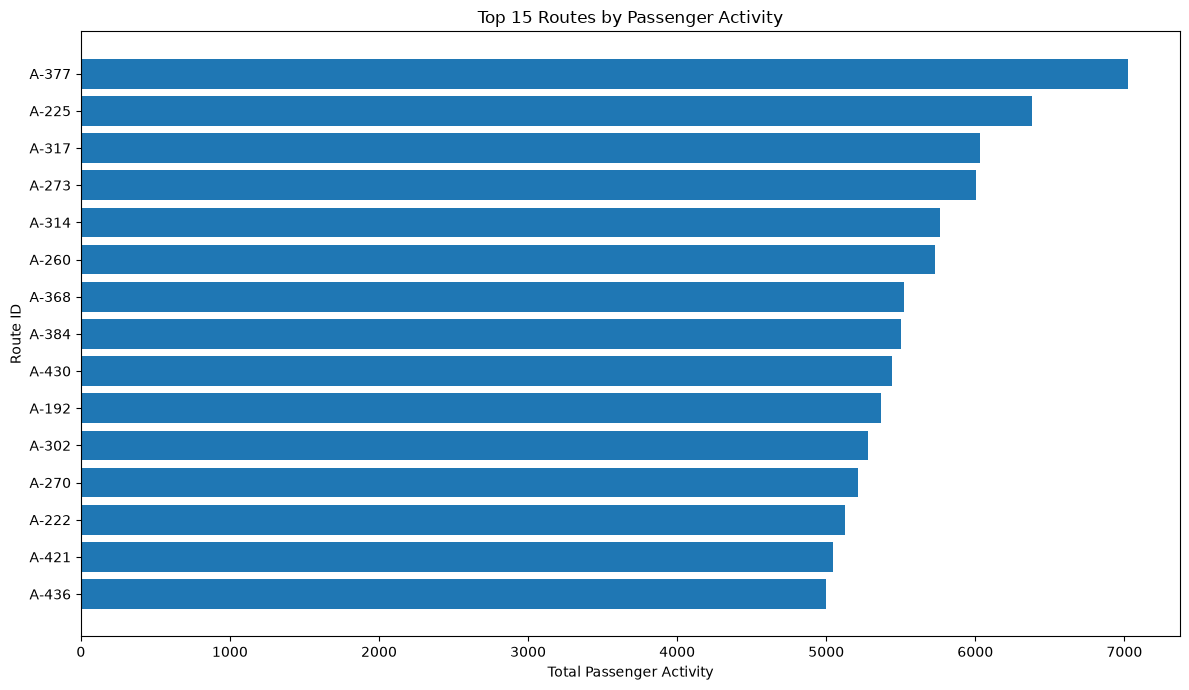

In [69]:
# ============================================================
# CHART 1
# ============================================================

top_routes = (
    route_performance
    .nlargest(15, "Passenger_Activity")
    .sort_values("Passenger_Activity")
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_routes["Route_ID"],
    top_routes["Passenger_Activity"]
)

plt.xlabel("Total Passenger Activity")
plt.ylabel("Route ID")
plt.title("Top 15 Routes by Passenger Activity")

plt.tight_layout()
plt.show()

<h2 style="color:black; font-size:25px; font-weight:bold;">Chart 2 — Top 20 stops by passenger activity</h2>

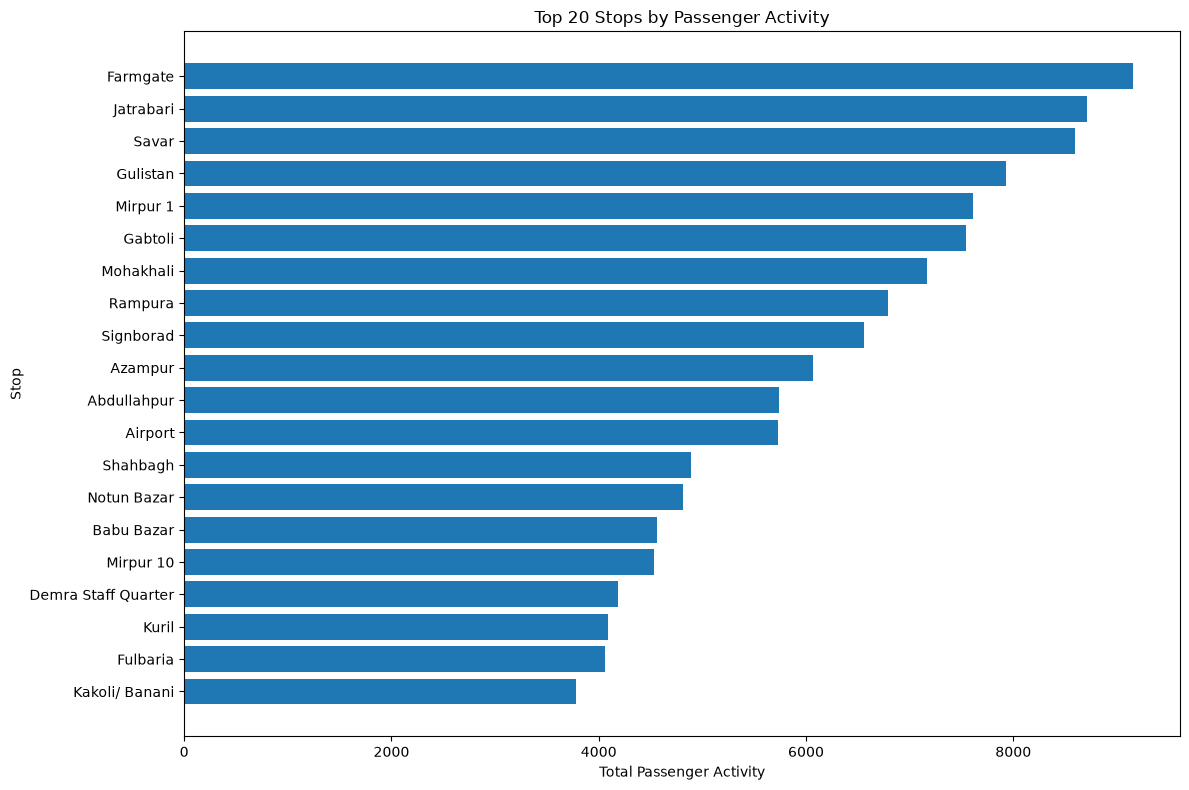

In [70]:
# ============================================================
# CHART 2
# ============================================================

top_stops = (
    stop_demand
    .nlargest(20, "Passenger_Activity")
    .sort_values("Passenger_Activity")
)

plt.figure(figsize=(12, 8))

plt.barh(
    top_stops["Name"],
    top_stops["Passenger_Activity"]
)

plt.xlabel("Total Passenger Activity")
plt.ylabel("Stop")
plt.title("Top 20 Stops by Passenger Activity")

plt.tight_layout()
plt.show()

<h2 style="color:black; font-size:25px; font-weight:bold;">Chart 3 — Hourly passenger activity</h2>

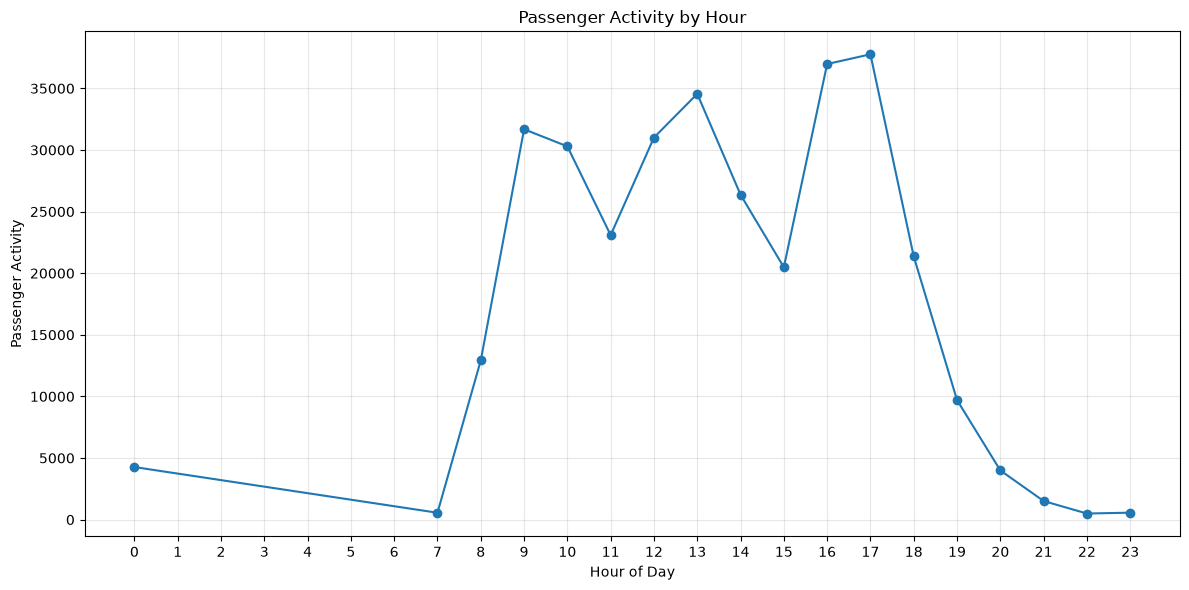

In [71]:
# ============================================================
# CHART 3
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    hourly_analysis["Hour"],
    hourly_analysis["Passenger_Activity"],
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Passenger Activity")
plt.title("Passenger Activity by Hour")

plt.xticks(
    range(
        int(hourly_analysis["Hour"].min()),
        int(hourly_analysis["Hour"].max()) + 1
    )
)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<h2 style="color:black; font-size:25px; font-weight:bold;">Chart 4 — Average occupancy by hour</h2>

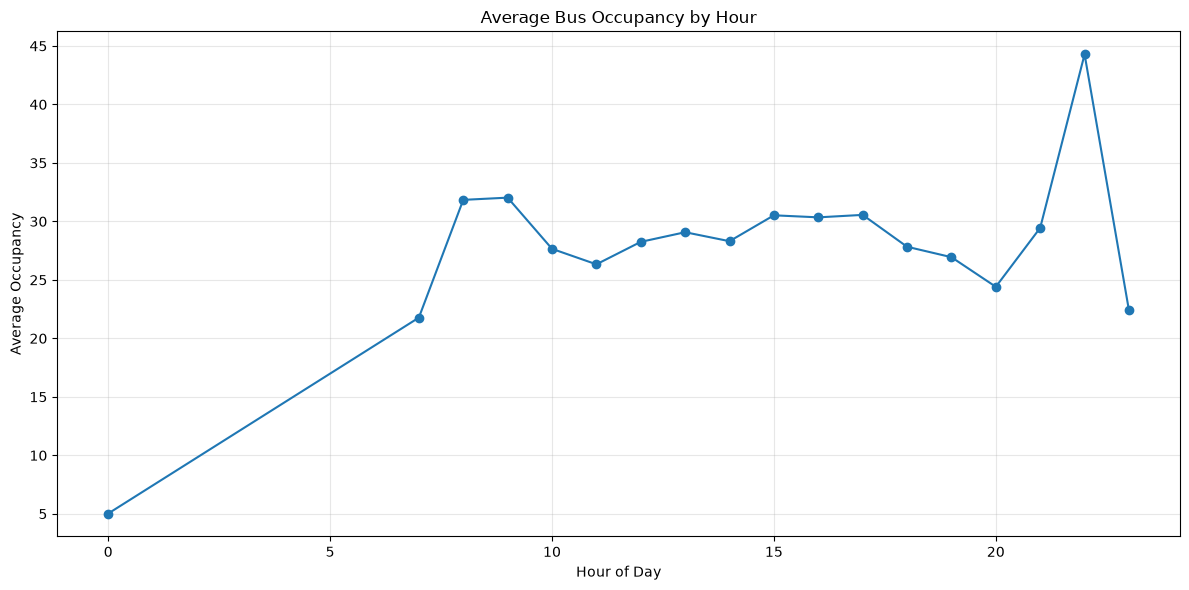

In [72]:
# ============================================================
# CHART 4
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    hourly_analysis["Hour"],
    hourly_analysis["Avg_Occupancy"],
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Occupancy")
plt.title("Average Bus Occupancy by Hour")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<h2 style="color:black; font-size:25px; font-weight:bold;">Chart 5 — Average travel and dwell time by hour</h2>

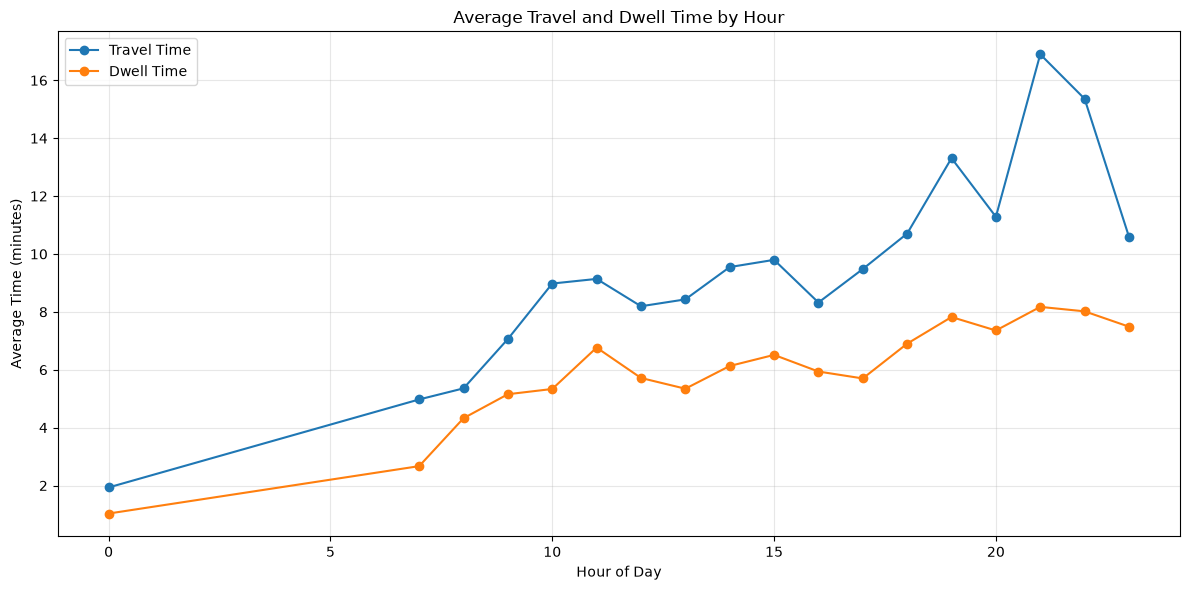

In [74]:
# ============================================================
# CHART 5
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    hourly_analysis["Hour"],
    hourly_analysis["Avg_Travel_Time_Min"],
    marker="o",
    label="Travel Time"
)

plt.plot(
    hourly_analysis["Hour"],
    hourly_analysis["Avg_Dwell_Time_Min"],
    marker="o",
    label="Dwell Time"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Time (minutes)")
plt.title("Average Travel and Dwell Time by Hour")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<h1 style="color:Red; font-size:30px; font-weight:bold;">16. CREATE A DASHBOARD</h1>

DATASET LOADED
Rows:    20,496
Columns: 13


PASSENGER FLOW RECONSTRUCTION VALIDATION


,Metric,Count,Percent_of_Total
0,Total records,20496,100.00
1,Valid observed occupancy,20331,99.19
2,Negative observed occupancy,164,0.80
3,Records with reconstructed occupancy,20496,100.00
4,Observed/reconstructed consistent,110,0.54
5,Observed/reconstructed inconsistent,20221,98.66
6,Negative reconstructed occupancy,9855,48.08


TOP 20 ROUTES BY PASSENGER ACTIVITY


,Route_ID,Records,Trips,Stops,Boarding,Alighting,Mean_Occupancy,Max_Occupancy,Mean_Travel_Time_Min,Mean_Dwell_Time_Min,Negative_Occupancy,Flow_Inconsistent,Passenger_Activity,Net_Passenger_Change,Negative_Occupancy_Rate_%,Flow_Inconsistency_Rate_%
64,A-377,306,18,17,"3,511.00","3,511.00",27.14,82.00,5.14,4.32,0,306,"7,022.00",0.00,0.00,100.00
27,A-225,180,4,10,"3,198.00","3,179.00",29.99,72.00,11.86,10.18,8,178,"6,377.00",19.00,4.44,98.89
54,A-317,270,18,15,"3,041.00","2,991.00",30.69,129.00,6.91,5.27,1,270,"6,032.00",50.00,0.37,100.00
42,A-273,306,18,17,"3,001.00","3,001.00",34.03,74.00,5.20,4.41,0,306,"6,002.00",0.00,0.00,100.00
53,A-314,306,18,17,"2,883.00","2,883.00",33.38,78.00,5.73,3.67,14,306,"5,766.00",0.00,4.58,100.00
37,A-260,126,18,7,"2,866.00","2,866.00",24.59,63.00,12.88,11.35,0,126,"5,732.00",0.00,0.00,100.00
63,A-368,324,18,18,"2,758.00","2,763.00",28.70,69.00,6.20,4.92,2,324,"5,521.00",-5.00,0.62,100.00
66,A-384,180,18,10,"2,736.00","2,767.00",25.74,71.00,15.14,7.76,4,180,"5,503.00",-31.00,2.22,100.00
73,A-430,342,18,19,"2,720.00","2,720.00",23.25,74.00,5.54,4.06,0,326,"5,440.00",0.00,0.00,95.32
20,A-192,270,18,15,"2,685.00","2,685.00",34.54,67.00,6.19,4.34,0,270,"5,370.00",0.00,0.00,100.00


TOP 20 STOPS BY PASSENGER ACTIVITY


,Route_ID,Name,Records,Trips,Boarding,Alighting,Mean_Occupancy,Max_Occupancy,Mean_Dwell_Time_Min,Negative_Occupancy,Passenger_Activity,Net_Passenger_Change,Negative_Occupancy_Rate_%
412,A-260,Savar,18,18,803.00,777.00,29.33,62.00,18.66,0,"1,580.00",26.00,0.00
394,A-252,Tarabo,18,18,705.00,745.00,33.94,52.00,18.55,0,"1,450.00",-40.00,0.00
147,A-141,Banasree,18,18,622.00,813.00,17.12,59.00,8.61,1,"1,435.00",-191.00,5.56
323,A-225,Azampur,18,4,669.00,680.00,36.41,60.00,16.62,1,"1,349.00",-11.00,5.56
269,A-207,Cherag Ali,18,18,742.00,577.00,22.56,87.00,60.29,0,"1,319.00",165.00,0.00
408,A-260,Dhamrai,18,18,616.00,688.00,14.33,57.00,10.00,0,"1,304.00",-72.00,0.00
316,A-224,Nabinagar,18,18,651.00,637.00,18.56,36.00,21.38,0,"1,288.00",14.00,0.00
844,A-412,Signborad,18,18,676.00,608.00,15.44,50.00,13.91,0,"1,284.00",68.00,0.00
184,A-166,Mohakhali,18,1,689.00,592.00,29.17,64.00,33.67,0,"1,281.00",97.00,0.00
936,A-436,Kuril,18,18,705.00,524.00,42.94,67.00,28.95,0,"1,229.00",181.00,0.00


TIME-PERIOD PERFORMANCE


,Time_Period,Records,Boarding,Alighting,Mean_Occupancy,Mean_Travel_Time_Min,Mean_Dwell_Time_Min,Passenger_Activity
0,Early Morning,1122,"2,042.00","2,225.00",5.02,1.93,1.03,"4,267.00"
1,Morning Peak,634,"10,382.00","3,099.00",31.28,5.34,4.23,"13,481.00"
2,Morning,3815,"42,197.00","42,866.00",28.90,8.32,5.66,"85,063.00"
3,Midday,4152,"45,998.00","45,937.00",28.58,8.66,5.69,"91,935.00"
4,Afternoon Peak,4068,"49,550.00","45,676.00",30.46,9.06,5.97,"95,226.00"
5,Evening,1273,"12,768.00","22,294.00",27.20,11.42,7.18,"35,062.00"
6,Night,79,889.00,"1,681.00",30.47,15.19,7.99,"2,570.00"
7,Unknown,5353,0.00,0.00,10.47,0.00,0.00,0.00


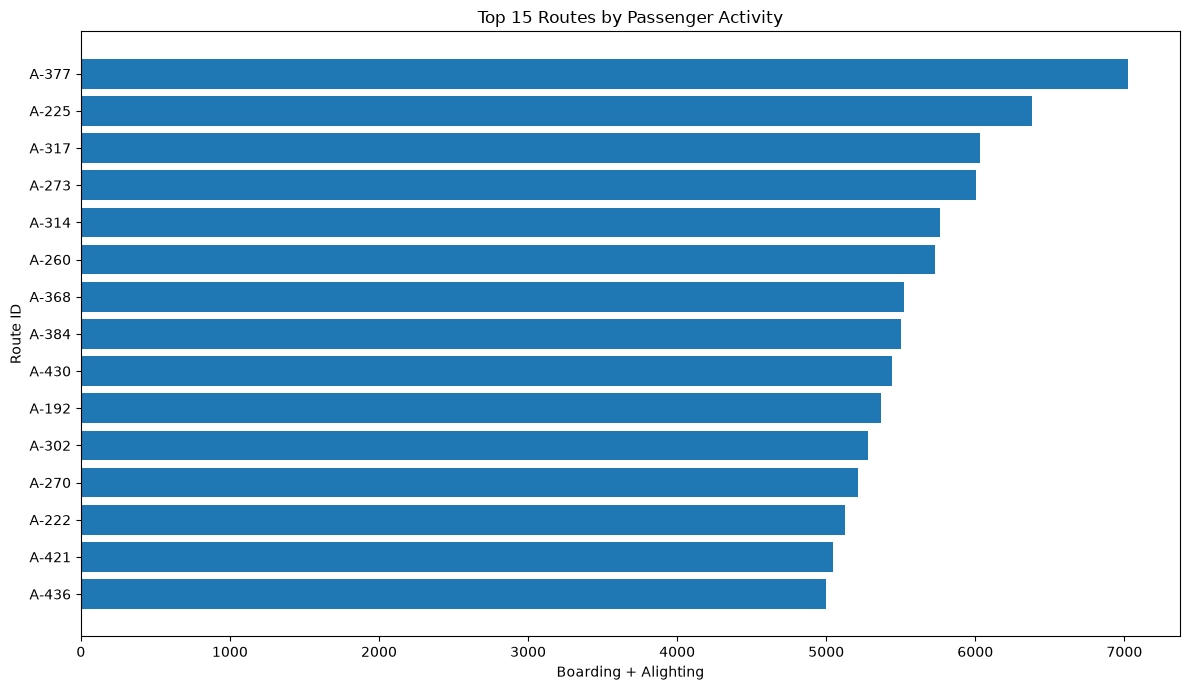

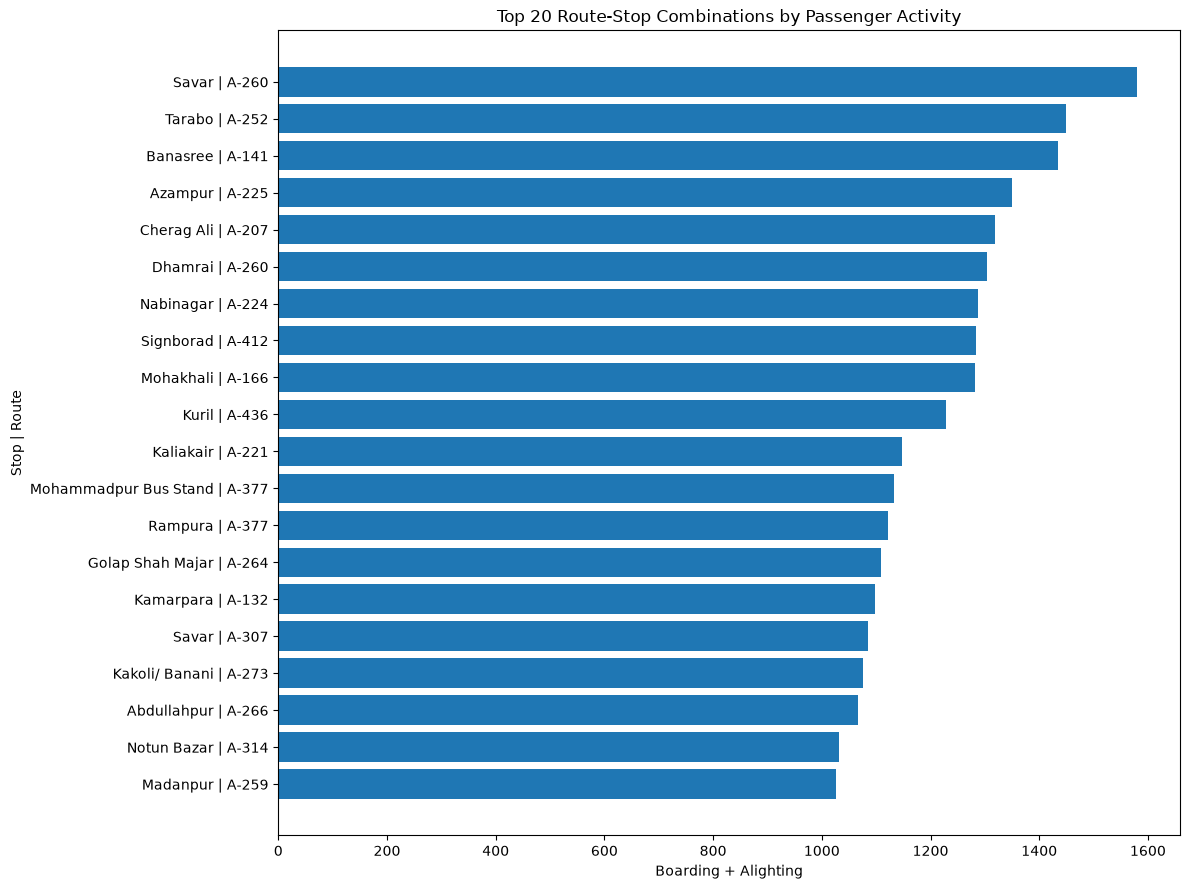

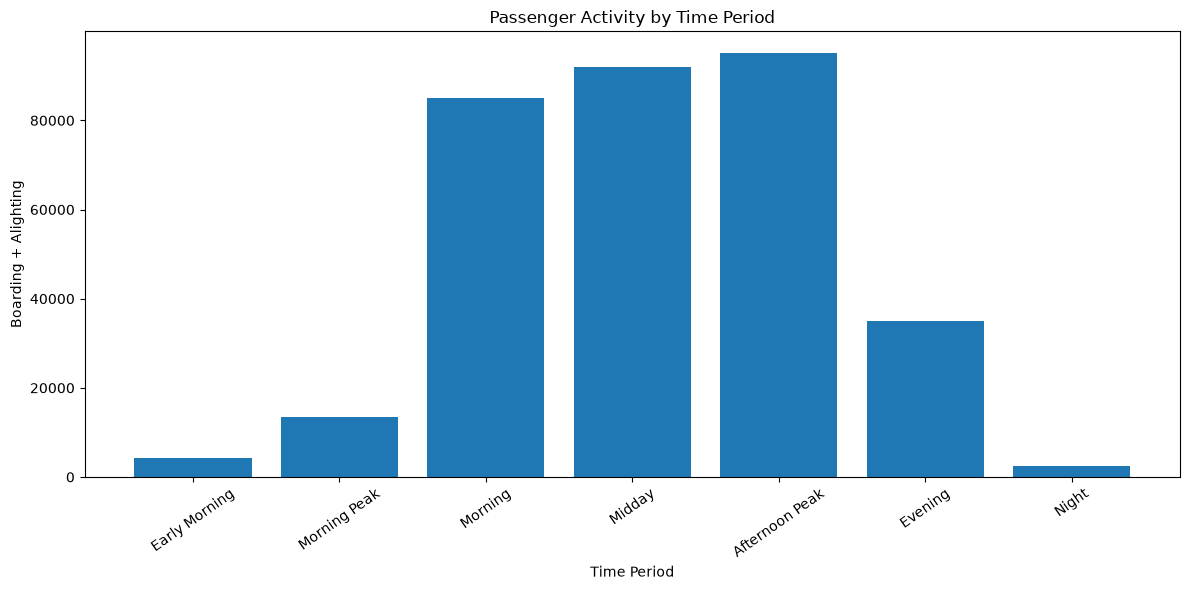

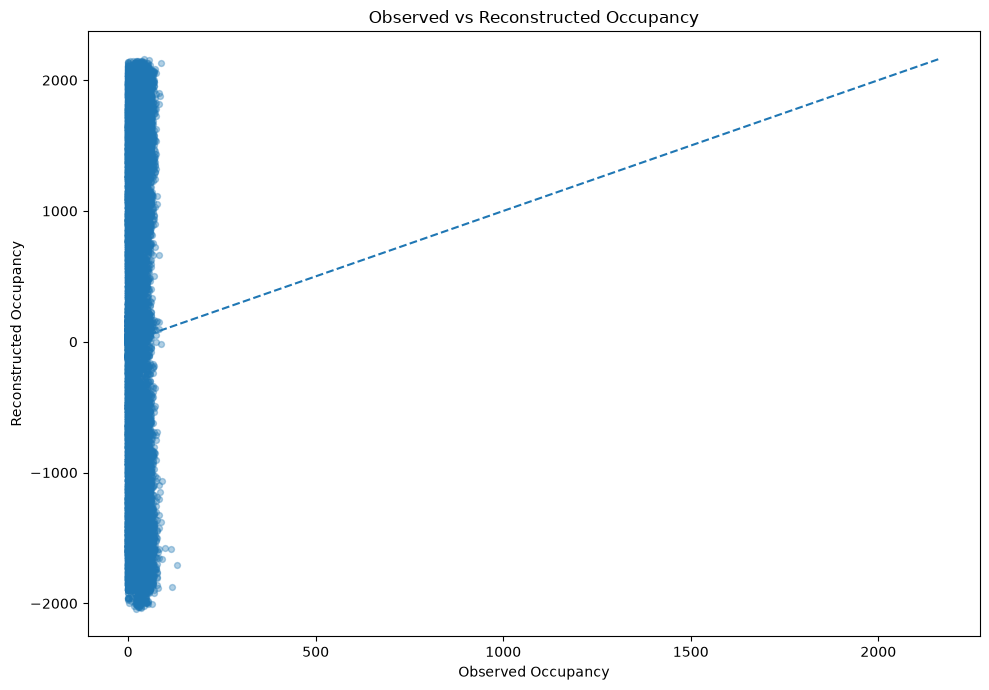

ANALYSIS COMPLETE
Available objects:
  df_raw
  df_analysis
  df_flow_validated
  validation_summary
  route_dashboard
  stop_dashboard
  period_dashboard


In [75]:
# ============================================================
# DTCA / BRR BUS SURVEY DATA
# PASSENGER FLOW RECONSTRUCTION + ROUTE/STOP DASHBOARD
# SELF-CONTAINED VERSION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


# ============================================================
# 1. LOAD DATA
# ============================================================

file_path = (
    r"E:\DTCA Project\BRR Project\Survey Data"
    r"\Data Processing\Data Visualization Code"
    r"\Python Anaconda\Data"
    r"\All_Processed_Survey_Data_Conda.csv"
)

df = pd.read_csv(
    file_path,
    encoding="latin1"
)

# Preserve original data
df_raw = df.copy()

# Working copy
df_analysis = df.copy()

print("=" * 80)
print("DATASET LOADED")
print("=" * 80)
print(f"Rows:    {len(df_analysis):,}")
print(f"Columns: {len(df_analysis.columns):,}")


# ============================================================
# 2. PREPARE TIME VARIABLES
# ============================================================

df_analysis["Time_Parsed"] = pd.to_datetime(
    df_analysis["Time"],
    format="%I:%M:%S %p",
    errors="coerce"
)

df_analysis["Hour"] = df_analysis["Time_Parsed"].dt.hour

df_analysis["Minute"] = df_analysis["Time_Parsed"].dt.minute

df_analysis["Decimal_Hour"] = (
    df_analysis["Hour"]
    + df_analysis["Minute"] / 60
)


def classify_period(hour):

    if pd.isna(hour):
        return "Unknown"
    elif hour < 6:
        return "Early Morning"
    elif hour < 9:
        return "Morning Peak"
    elif hour < 12:
        return "Morning"
    elif hour < 15:
        return "Midday"
    elif hour < 18:
        return "Afternoon Peak"
    elif hour < 21:
        return "Evening"
    else:
        return "Night"


df_analysis["Time_Period"] = (
    df_analysis["Hour"].apply(classify_period)
)


# ============================================================
# 3. CLEAN PASSENGER VARIABLES
# ============================================================

df_analysis["Boarding_Clean"] = (
    pd.to_numeric(
        df_analysis["Boarding"],
        errors="coerce"
    ).fillna(0)
)

df_analysis["Alighting_Clean"] = (
    pd.to_numeric(
        df_analysis["Alighting"],
        errors="coerce"
    ).fillna(0)
)

df_analysis["Occupancy_Numeric"] = (
    pd.to_numeric(
        df_analysis["Occupancy"],
        errors="coerce"
    )
)

# Negative observed occupancy is treated as invalid
df_analysis["Observed_Occupancy_Clean"] = (
    df_analysis["Occupancy_Numeric"]
    .where(df_analysis["Occupancy_Numeric"] >= 0)
)

# Passenger change at each stop
df_analysis["Net_Change"] = (
    df_analysis["Boarding_Clean"]
    -
    df_analysis["Alighting_Clean"]
)


# ============================================================
# 4. CLEAN TRAVEL / DWELL TIME
# ============================================================

df_analysis["Travel_Time_Clean"] = (
    pd.to_numeric(
        df_analysis["Travel Time (s)"],
        errors="coerce"
    )
    .where(
        pd.to_numeric(
            df_analysis["Travel Time (s)"],
            errors="coerce"
        ) >= 0
    )
)

df_analysis["Dwell_Time_Clean"] = (
    pd.to_numeric(
        df_analysis["Dwell Time (s)"],
        errors="coerce"
    )
    .where(
        pd.to_numeric(
            df_analysis["Dwell Time (s)"],
            errors="coerce"
        ) >= 0
    )
)

df_analysis["Travel_Time_Min"] = (
    df_analysis["Travel_Time_Clean"] / 60
)

df_analysis["Dwell_Time_Min"] = (
    df_analysis["Dwell_Time_Clean"] / 60
)


# ============================================================
# 5. SORT TRIPS
# ============================================================

flow = df_analysis.copy()

# Preserve original row number
flow["_Original_Row"] = np.arange(len(flow))

flow["Sequence"] = pd.to_numeric(
    flow["Sequence"],
    errors="coerce"
)

# Sort by trip and sequence
flow = flow.sort_values(
    ["Trip_ID", "Sequence", "_Original_Row"],
    kind="stable"
).copy()


# ============================================================
# 6. PREVIOUS OBSERVED OCCUPANCY
# ============================================================

flow["Previous_Observed_Occupancy"] = (
    flow
    .groupby("Trip_ID", dropna=False)
    ["Observed_Occupancy_Clean"]
    .shift(1)
)


# ============================================================
# 7. RECONSTRUCT PASSENGER OCCUPANCY
# ============================================================

def reconstruct_trip(g):

    g = g.copy()

    observed = (
        g["Observed_Occupancy_Clean"]
        .to_numpy(dtype=float)
    )

    boarding = (
        g["Boarding_Clean"]
        .to_numpy(dtype=float)
    )

    alighting = (
        g["Alighting_Clean"]
        .to_numpy(dtype=float)
    )

    reconstructed = np.full(
        len(g),
        np.nan
    )

    # Find first valid observed occupancy
    valid_positions = np.where(
        ~np.isnan(observed)
    )[0]

    if len(valid_positions) == 0:
        return pd.Series(
            reconstructed,
            index=g.index
        )

    first = valid_positions[0]

    # Anchor reconstruction at first valid observation
    reconstructed[first] = observed[first]

    # Move forward through trip
    for i in range(first + 1, len(g)):

        reconstructed[i] = (
            reconstructed[i - 1]
            +
            boarding[i]
            -
            alighting[i]
        )

    # Move backward before first observation
    for i in range(first - 1, -1, -1):

        reconstructed[i] = (
            reconstructed[i + 1]
            -
            boarding[i + 1]
            +
            alighting[i + 1]
        )

    return pd.Series(
        reconstructed,
        index=g.index
    )


flow["Reconstructed_Occupancy"] = (
    flow
    .groupby(
        "Trip_ID",
        dropna=False,
        group_keys=False
    )
    .apply(reconstruct_trip)
)


# ============================================================
# 8. VALIDATE OBSERVED VS RECONSTRUCTED OCCUPANCY
# ============================================================

flow["Occupancy_Residual"] = (
    flow["Observed_Occupancy_Clean"]
    -
    flow["Reconstructed_Occupancy"]
)

flow["Flow_Consistent"] = (
    flow["Occupancy_Residual"].abs() < 1e-6
)

flow["Reconstructed_Negative"] = (
    flow["Reconstructed_Occupancy"] < 0
)

flow["Observed_Negative"] = (
    flow["Occupancy_Numeric"] < 0
)


# ============================================================
# 9. VALIDATION SUMMARY
# ============================================================

total_records = len(flow)

observed_valid = (
    flow["Observed_Occupancy_Clean"]
    .notna()
    .sum()
)

observed_negative = (
    flow["Observed_Negative"]
    .sum()
)

reconstructed_valid = (
    flow["Reconstructed_Occupancy"]
    .notna()
    .sum()
)

consistent = (
    flow.loc[
        flow["Observed_Occupancy_Clean"].notna(),
        "Flow_Consistent"
    ]
    .sum()
)

inconsistent = (
    observed_valid - consistent
)

negative_reconstructed = (
    flow["Reconstructed_Negative"]
    .sum()
)


validation_summary = pd.DataFrame({

    "Metric": [

        "Total records",

        "Valid observed occupancy",

        "Negative observed occupancy",

        "Records with reconstructed occupancy",

        "Observed/reconstructed consistent",

        "Observed/reconstructed inconsistent",

        "Negative reconstructed occupancy"
    ],

    "Count": [

        total_records,

        observed_valid,

        observed_negative,

        reconstructed_valid,

        consistent,

        inconsistent,

        negative_reconstructed
    ]
})

validation_summary["Percent_of_Total"] = (
    validation_summary["Count"]
    /
    total_records
    *
    100
)


# ============================================================
# 10. ROUTE PERFORMANCE
# ============================================================

route_dashboard = (

    flow
    .groupby(
        "Route_ID",
        dropna=False
    )
    .agg(

        Records=("Route_ID", "size"),

        Trips=("Trip_ID", "nunique"),

        Stops=("Name", "nunique"),

        Boarding=("Boarding_Clean", "sum"),

        Alighting=("Alighting_Clean", "sum"),

        Mean_Occupancy=(
            "Observed_Occupancy_Clean",
            "mean"
        ),

        Max_Occupancy=(
            "Observed_Occupancy_Clean",
            "max"
        ),

        Mean_Travel_Time_Min=(
            "Travel_Time_Min",
            "mean"
        ),

        Mean_Dwell_Time_Min=(
            "Dwell_Time_Min",
            "mean"
        ),

        Negative_Occupancy=(
            "Observed_Negative",
            "sum"
        ),

        Flow_Inconsistent=(
            "Flow_Consistent",
            lambda x: (~x).sum()
        )
    )

    .reset_index()
)


route_dashboard["Passenger_Activity"] = (
    route_dashboard["Boarding"]
    +
    route_dashboard["Alighting"]
)

route_dashboard["Net_Passenger_Change"] = (
    route_dashboard["Boarding"]
    -
    route_dashboard["Alighting"]
)

route_dashboard["Negative_Occupancy_Rate_%"] = (
    route_dashboard["Negative_Occupancy"]
    /
    route_dashboard["Records"]
    *
    100
)

route_dashboard["Flow_Inconsistency_Rate_%"] = (
    route_dashboard["Flow_Inconsistent"]
    /
    route_dashboard["Records"]
    *
    100
)

route_dashboard = route_dashboard.sort_values(
    "Passenger_Activity",
    ascending=False
)


# ============================================================
# 11. STOP PERFORMANCE
# ============================================================

stop_dashboard = (

    flow
    .groupby(
        ["Route_ID", "Name"],
        dropna=False
    )
    .agg(

        Records=("Name", "size"),

        Trips=("Trip_ID", "nunique"),

        Boarding=("Boarding_Clean", "sum"),

        Alighting=("Alighting_Clean", "sum"),

        Mean_Occupancy=(
            "Observed_Occupancy_Clean",
            "mean"
        ),

        Max_Occupancy=(
            "Observed_Occupancy_Clean",
            "max"
        ),

        Mean_Dwell_Time_Min=(
            "Dwell_Time_Min",
            "mean"
        ),

        Negative_Occupancy=(
            "Observed_Negative",
            "sum"
        )
    )

    .reset_index()
)

stop_dashboard["Passenger_Activity"] = (
    stop_dashboard["Boarding"]
    +
    stop_dashboard["Alighting"]
)

stop_dashboard["Net_Passenger_Change"] = (
    stop_dashboard["Boarding"]
    -
    stop_dashboard["Alighting"]
)

stop_dashboard["Negative_Occupancy_Rate_%"] = (
    stop_dashboard["Negative_Occupancy"]
    /
    stop_dashboard["Records"]
    *
    100
)

stop_dashboard = stop_dashboard.sort_values(
    "Passenger_Activity",
    ascending=False
)


# ============================================================
# 12. TIME PERIOD PERFORMANCE
# ============================================================

period_order = [

    "Early Morning",
    "Morning Peak",
    "Morning",
    "Midday",
    "Afternoon Peak",
    "Evening",
    "Night",
    "Unknown"
]

period_dashboard = (

    flow
    .groupby(
        "Time_Period",
        dropna=False
    )
    .agg(

        Records=("Time_Period", "size"),

        Boarding=("Boarding_Clean", "sum"),

        Alighting=("Alighting_Clean", "sum"),

        Mean_Occupancy=(
            "Observed_Occupancy_Clean",
            "mean"
        ),

        Mean_Travel_Time_Min=(
            "Travel_Time_Min",
            "mean"
        ),

        Mean_Dwell_Time_Min=(
            "Dwell_Time_Min",
            "mean"
        )
    )
    .reindex(period_order)
    .reset_index()
)

period_dashboard["Passenger_Activity"] = (
    period_dashboard["Boarding"]
    +
    period_dashboard["Alighting"]
)


# ============================================================
# 13. DISPLAY VALIDATION RESULTS
# ============================================================

print("\n")
print("=" * 80)
print("PASSENGER FLOW RECONSTRUCTION VALIDATION")
print("=" * 80)

display(validation_summary)


print("=" * 80)
print("TOP 20 ROUTES BY PASSENGER ACTIVITY")
print("=" * 80)

display(
    route_dashboard.head(20)
)


print("=" * 80)
print("TOP 20 STOPS BY PASSENGER ACTIVITY")
print("=" * 80)

display(
    stop_dashboard.head(20)
)


print("=" * 80)
print("TIME-PERIOD PERFORMANCE")
print("=" * 80)

display(
    period_dashboard
)


# ============================================================
# 14. VISUAL 1 — ROUTE PASSENGER ACTIVITY
# ============================================================

top_routes = (
    route_dashboard
    .head(15)
    .sort_values("Passenger_Activity")
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_routes["Route_ID"].astype(str),
    top_routes["Passenger_Activity"]
)

plt.title(
    "Top 15 Routes by Passenger Activity"
)

plt.xlabel(
    "Boarding + Alighting"
)

plt.ylabel(
    "Route ID"
)

plt.tight_layout()

plt.show()


# ============================================================
# 15. VISUAL 2 — TOP STOPS
# ============================================================

top_stops = (
    stop_dashboard
    .head(20)
    .sort_values("Passenger_Activity")
)

stop_labels = (
    top_stops["Name"].astype(str)
    +
    " | "
    +
    top_stops["Route_ID"].astype(str)
)

plt.figure(figsize=(12, 9))

plt.barh(
    stop_labels,
    top_stops["Passenger_Activity"]
)

plt.title(
    "Top 20 Route-Stop Combinations by Passenger Activity"
)

plt.xlabel(
    "Boarding + Alighting"
)

plt.ylabel(
    "Stop | Route"
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. VISUAL 3 — TIME PERIOD
# ============================================================

plot_period = (
    period_dashboard[
        period_dashboard["Time_Period"] != "Unknown"
    ]
    .dropna(subset=["Time_Period"])
)

plt.figure(figsize=(12, 6))

plt.bar(
    plot_period["Time_Period"],
    plot_period["Passenger_Activity"]
)

plt.title(
    "Passenger Activity by Time Period"
)

plt.xlabel(
    "Time Period"
)

plt.ylabel(
    "Boarding + Alighting"
)

plt.xticks(rotation=35)

plt.tight_layout()

plt.show()


# ============================================================
# 17. VISUAL 4 — OCCUPANCY RECONCILIATION
# ============================================================

recon_data = flow[
    flow["Observed_Occupancy_Clean"].notna()
    &
    flow["Reconstructed_Occupancy"].notna()
]

plt.figure(figsize=(10, 7))

plt.scatter(
    recon_data["Observed_Occupancy_Clean"],
    recon_data["Reconstructed_Occupancy"],
    alpha=0.35,
    s=18
)

max_value = max(
    recon_data["Observed_Occupancy_Clean"].max(),
    recon_data["Reconstructed_Occupancy"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.title(
    "Observed vs Reconstructed Occupancy"
)

plt.xlabel(
    "Observed Occupancy"
)

plt.ylabel(
    "Reconstructed Occupancy"
)

plt.tight_layout()

plt.show()


# ============================================================
# 18. SAVE FINAL ANALYSIS OBJECTS IN MEMORY
# ============================================================

df_flow_validated = flow.copy()

print("=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)

print(
    "Available objects:"
)

print("  df_raw")
print("  df_analysis")
print("  df_flow_validated")
print("  validation_summary")
print("  route_dashboard")
print("  stop_dashboard")
print("  period_dashboard")